# KMRF Model - Comprehensive Test Notebook

This notebook demonstrates the complete KMRF (KAMA+MSR+RF) regime prediction pipeline:
1. Loading pre-computed features from the 'ready' folder
2. Loading KAMA+MSR regime labels from saved models
3. Adapting 4-regime labels to 3-class KMRF labels
4. Loading and combining macroeconomic features
5. (Optional) Feature selection with BorutaShap
6. Preparing final training data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import kmrf as km

%matplotlib inline

## 1. Initialize KMRF Model

In [2]:
# Initialize KMRF for US equities
kmrf_model = km.KMRF(
    asset_class='us_equity',
    end_date='20190101',
    use_ready_data=True,
    random_seed=42
)

print(f"\n{kmrf_model}")

KMRF model initialized
  Asset class: us_equity
  End date: 20190101
  Using pre-computed features: True
  Data path: data/ready/us_equity.csv
  KAMA+MSR model directory: saved_models/KAMA_MSR/us_equity/20190101
  Random seed: 42

KMRF(us_equity, 20190101)


## 2. Load Data and Features

In [3]:
# Load pre-computed features
data = kmrf_model.load_data()
features = kmrf_model.get_features()

print(f"\nAssets: {kmrf_model.asset_names}")


Loading data from: data/ready/us_equity.csv
Loaded 9022 rows, 21 assets
Date range: 1990-01-02 00:00:00 to 2025-10-24 00:00:00
Assets: SPDR S&P 500 ETF, Invesco S&P 500 Equal Weight ETF, Fidelity Nasdaq Composite Index ETF, Invesco QQQ Trust, iShares Russell 2000 ETF...

Extracting pre-computed features...
Features shape: (9022, 2751)
Assets: 21

Assets: ['SPDR S&P 500 ETF', 'Invesco S&P 500 Equal Weight ETF', 'Fidelity Nasdaq Composite Index ETF', 'Invesco QQQ Trust', 'iShares Russell 2000 ETF', 'SPDR Dow Jones Industrial Average ETF', 'Energy Select Sector SPDR', 'Financial Select Sector SPDR', 'Utilities Select Sector SPDR', 'Industrial Select Sector SPDR', 'Health Care Select Sector SPDR', 'Technology Select Sector SPDR', 'Materials Select Sector SPDR', 'Consumer Discretionary Select Sector SPDR', 'Consumer Staples Select Sector SPDR', 'iShares S&P 500 Growth ETF', 'iShares S&P 500 Value ETF', 'iShares Russell 2000 Growth ETF', 'iShares Russell 2000 Value ETF', 'iShares Russell Mi

## 3. Load KAMA+MSR Labels

In [4]:
# Load original 4-regime labels from saved models
original_labels = kmrf_model.load_kama_msr_labels()


LOADING KAMA+MSR LABELS FOR 21 ASSETS
Model directory: saved_models/KAMA_MSR/us_equity/20190101
[1/21] ✓ Loaded labels for: SPDR S&P 500 ETF
[2/21] ✓ Loaded labels for: Invesco S&P 500 Equal Weight ETF
[3/21] ✓ Loaded labels for: Fidelity Nasdaq Composite Index ETF
[4/21] ✓ Loaded labels for: Invesco QQQ Trust
[5/21] ✓ Loaded labels for: iShares Russell 2000 ETF
[6/21] ✓ Loaded labels for: SPDR Dow Jones Industrial Average ETF
[7/21] ✓ Loaded labels for: Energy Select Sector SPDR
[8/21] ✓ Loaded labels for: Financial Select Sector SPDR
[9/21] ✓ Loaded labels for: Utilities Select Sector SPDR
[10/21] ✓ Loaded labels for: Industrial Select Sector SPDR
[11/21] ✓ Loaded labels for: Health Care Select Sector SPDR
[12/21] ✓ Loaded labels for: Technology Select Sector SPDR
[13/21] ✓ Loaded labels for: Materials Select Sector SPDR
[14/21] ✓ Loaded labels for: Consumer Discretionary Select Sector SPDR
[15/21] ✓ Loaded labels for: Consumer Staples Select Sector SPDR
[16/21] ✓ Loaded labels for:

## 4. Adapt Labels (4-regime → 3-class)

In [5]:
# Adapt to 3-class KMRF labels
adapted_labels = kmrf_model.adapt_regime_labels()


ADAPTING REGIME LABELS

Processing: SPDR S&P 500 ETF
  Label distribution:
     Bearish (-1):   821 ( 13.6%)
       Other ( 0):   312 (  5.2%)
     Bullish ( 1):  4908 ( 81.2%)

Processing: Invesco S&P 500 Equal Weight ETF
  Label distribution:
     Bearish (-1):   286 (  4.7%)
       Other ( 0):  2375 ( 39.3%)
     Bullish ( 1):  3380 ( 56.0%)

Processing: Fidelity Nasdaq Composite Index ETF
  Label distribution:
     Bearish (-1):   161 (  2.7%)
       Other ( 0):  2859 ( 47.3%)
     Bullish ( 1):  3021 ( 50.0%)

Processing: Invesco QQQ Trust
  Label distribution:
     Bearish (-1):   778 ( 12.9%)
       Other ( 0):  1479 ( 24.5%)
     Bullish ( 1):  3784 ( 62.6%)

Processing: iShares Russell 2000 ETF
  Label distribution:
     Bearish (-1):   539 (  8.9%)
       Other ( 0):  1937 ( 32.1%)
     Bullish ( 1):  3565 ( 59.0%)

Processing: SPDR Dow Jones Industrial Average ETF
  Label distribution:
     Bearish (-1):   415 (  6.9%)
       Other ( 0):  1110 ( 18.4%)
     Bullish ( 1):  4

## 5. Examine SPY Labels

In [6]:
spy_name = 'SPDR S&P 500 ETF'

# Extract SPY labels
original_spy = original_labels.xs(spy_name, level=0, axis=1)['regime_label']
adapted_spy = adapted_labels.xs(spy_name, level=0, axis=1)['adapted_regime']
spy_features = features.xs(spy_name, level=0, axis=1)

# Get close price
close_cols = [col for col in spy_features.columns if 'close' in col.lower() and 'sma' not in col.lower()]
close_price = spy_features[close_cols[0]] if close_cols else None

print("SPY Label Statistics:")
print("="*60)

# Original
print("\nOriginal 4-Regime:")
orig_names = {0: 'LV Bullish', 1: 'LV Bearish', 2: 'HV Bullish', 3: 'HV Bearish'}
for regime in [0, 1, 2, 3]:
    count = (original_spy == regime).sum()
    pct = (count / len(original_spy.dropna())) * 100
    print(f"  {regime} - {orig_names[regime]:>12}: {count:>5} ({pct:>5.1f}%)")

# Adapted
print("\nAdapted 3-Class:")
adapt_names = {1: 'Bullish', 0: 'Other', -1: 'Bearish'}
for regime in [1, 0, -1]:
    count = (adapted_spy == regime).sum()
    pct = (count / len(adapted_spy)) * 100
    print(f"  {regime:>2} - {adapt_names[regime]:>8}: {count:>5} ({pct:>5.1f}%)")

print("="*60)

SPY Label Statistics:

Original 4-Regime:
  0 -   LV Bullish:  4560 ( 75.7%)
  1 -   LV Bearish:  1138 ( 18.9%)
  2 -   HV Bullish:    26 (  0.4%)
  3 -   HV Bearish:   299 (  5.0%)

Adapted 3-Class:
   1 -  Bullish:  4908 ( 81.2%)
   0 -    Other:   312 (  5.2%)
  -1 -  Bearish:   821 ( 13.6%)


## 6. Visualize Adapted Labels on Price Chart

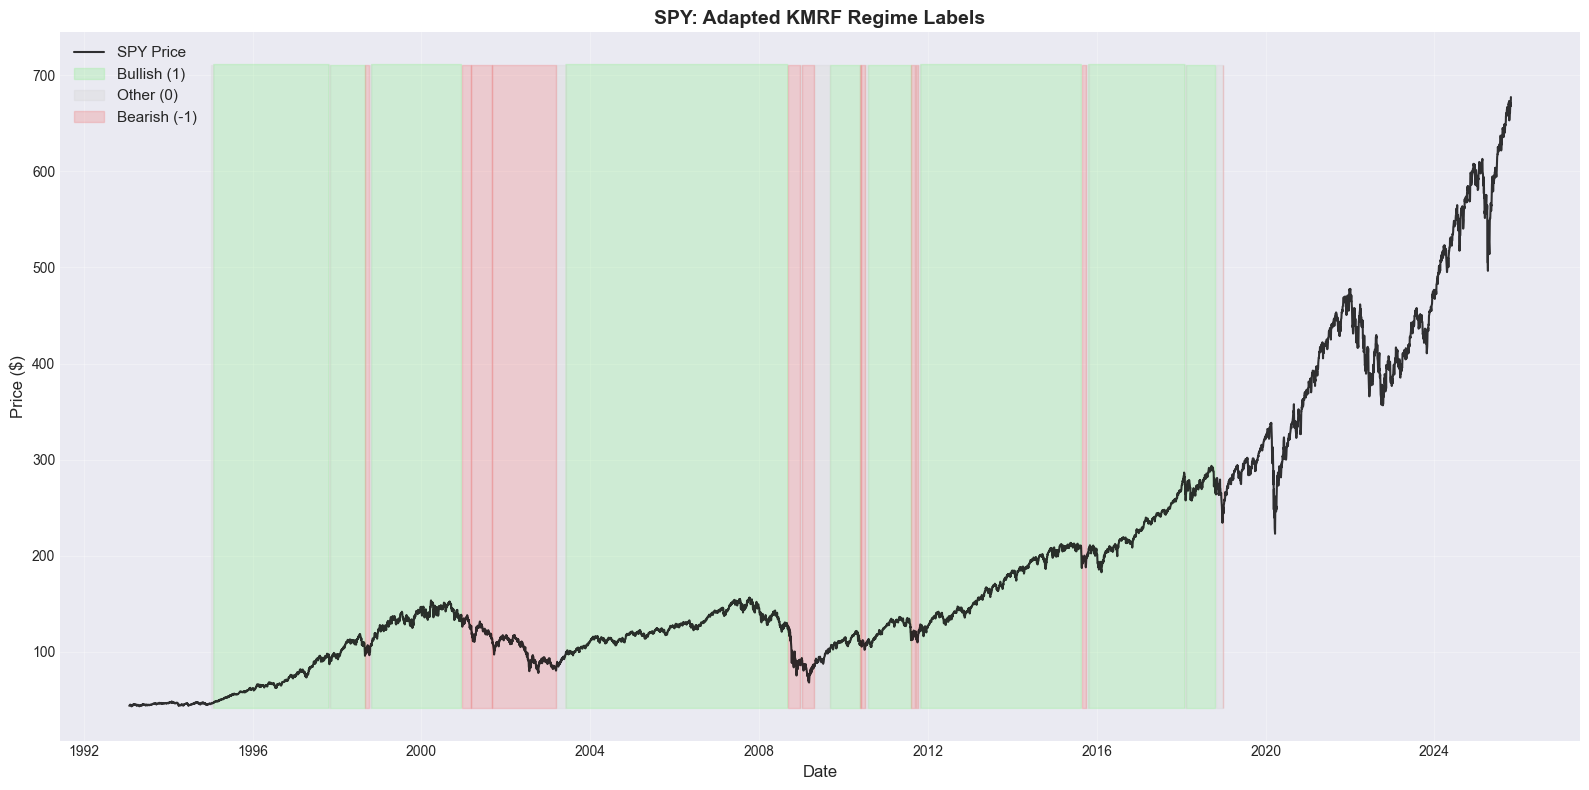

✓ Visualization complete!


In [7]:
if close_price is not None:
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Plot price
    ax.plot(close_price.index, close_price, color='black', linewidth=1.5, 
            alpha=0.8, label='SPY Price', zorder=3)
    
    # Define colors
    colors = {1: 'lightgreen', 0: 'lightgray', -1: 'lightcoral'}
    labels_dict = {1: 'Bullish', 0: 'Other', -1: 'Bearish'}
    
    # Shade regions
    for regime in [1, 0, -1]:
        mask = adapted_spy == regime
        if mask.any():
            ax.fill_between(
                close_price.index,
                close_price.min() * 0.95,
                close_price.max() * 1.05,
                where=mask.reindex(close_price.index, fill_value=False),
                alpha=0.3,
                color=colors[regime],
                label=f'{labels_dict[regime]} ({regime})',
                zorder=1
            )
    
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Price ($)', fontsize=12)
    ax.set_title('SPY: Adapted KMRF Regime Labels', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3, zorder=2)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Visualization complete!")
else:
    print("Price data not available")

## 7. Prepare Training Data (Full Pipeline)

In [8]:
# Prepare training data with all features
# Set select_features=True to use BorutaShap (may take time)
X, y = kmrf_model.prepare_training_data(
    transform_labels=True,
    include_macro=True,
    select_features=False,  # Set to True to use BorutaShap
    align_indices=True
)


PREPARING TRAINING DATA



Step 1: Technical Features
  Shape: (9022, 2751)

Step 2: Loading Macroeconomic Data

Loading macroeconomic data from: data/ready/macro_data_all.csv
Aligned macro data to features index
Macro data shape: (9022, 52)
Macro indicators: 52
  Combined shape: (9022, 2803)

Step 3: Transforming Labels
  4-regime → 3-class (Bullish=1, Bearish=-1, Other=0)

ADAPTING REGIME LABELS

Processing: SPDR S&P 500 ETF
  Label distribution:
     Bearish (-1):   821 ( 13.6%)
       Other ( 0):   312 (  5.2%)
     Bullish ( 1):  4908 ( 81.2%)

Processing: Invesco S&P 500 Equal Weight ETF
  Label distribution:
     Bearish (-1):   286 (  4.7%)
       Other ( 0):  2375 ( 39.3%)
     Bullish ( 1):  3380 ( 56.0%)

Processing: Fidelity Nasdaq Composite Index ETF
  Label distribution:
     Bearish (-1):   161 (  2.7%)
       Other ( 0):  2859 ( 47.3%)
     Bullish ( 1):  3021 ( 50.0%)

Processing: Invesco QQQ Trust
  Label distribution:
     Bearish (-1):   778 ( 12.9%)
       Other ( 0):  1479 ( 24.5%)
     Bu

## 8. Examine Final Training Data

In [9]:
# Extract SPY data
spy_X = X.xs(spy_name, level=0, axis=1)
spy_y = y.xs(spy_name, level=0, axis=1)

print("Final Training Data for SPY:")
print("="*60)
print(f"Features: {spy_X.shape}")
print(f"Labels: {spy_y.shape}")
print(f"Date range: {spy_X.index[0]} to {spy_X.index[-1]}")
print(f"Missing values: {spy_X.isna().sum().sum()}")

# Feature categories
feature_names = spy_X.columns.tolist()
print(f"\nFeature Types:")
print(f"  Returns: {len([f for f in feature_names if 'ret' in str(f).lower()])}")
print(f"  Volatility: {len([f for f in feature_names if 'vol' in str(f).lower()])}")
print(f"  Momentum: {len([f for f in feature_names if 'momentum' in str(f).lower() or 'rsi' in str(f).lower()])}")
print(f"  Technical: {len([f for f in feature_names if any(x in str(f).lower() for x in ['sma', 'ema', 'bb_', 'macd'])])}")
print(f"  Tsfresh: {len([f for f in feature_names if 'tsfresh' in str(f).lower()])}")

print("\n" + "="*60)
print("✓ Data ready for Random Forest training!")
print("="*60)

Final Training Data for SPY:
Features: (6041, 131)
Labels: (6041, 1)
Date range: 1995-01-04 00:00:00 to 2018-12-31 00:00:00
Missing values: 0

Feature Types:
  Returns: 16
  Volatility: 40
  Momentum: 7
  Technical: 19
  Tsfresh: 40

✓ Data ready for Random Forest training!


## Summary

This notebook demonstrated the complete KMRF data preparation pipeline:

### Completed Steps:
1. ✓ Initialized KMRF model with pre-computed features
2. ✓ Loaded multi-asset data from 'ready' folder
3. ✓ Loaded KAMA+MSR 4-regime labels from saved models
4. ✓ Adapted labels to 3-class KMRF format (Bullish/Bearish/Other)
5. ✓ Visualized adapted labels on price chart
6. ✓ Prepared final training data with macro features

### Key Features:
- **Label Transformation**: 4-regime KAMA+MSR → 3-class KMRF
  - Bullish (1): LV Bullish + extension to HV Bullish peak
  - Bearish (-1): HV Bearish + extension to LV Bearish trough
  - Other (0): Remaining periods
  
- **Feature Combination**: Technical + Macro (optional)
- **Feature Selection**: BorutaShap (optional, set select_features=True)

### Next Steps:
1. Train Random Forest classifier on prepared data
2. Apply contrarian trading strategy:
   - High P(Bullish) → Short (overbought)
   - High P(Bearish) → Long (oversold)
   - High P(Other) → Close position
3. Evaluate performance:
   - Matthews Correlation Coefficient (MCC)
   - Sortino Ratio
   - Information Ratio vs benchmarks

### Paper References:
- Pomorski & Gorse (2023): "Improving Portfolio Performance Using a Novel Method for Predicting Financial Regimes"
- Feature selection reduces ~60+ features → ~24-131 features (asset class dependent)
- Contrarian interpretation crucial for profitability